# Task 4.3 — Single Strain HAI Vic B/Austria/1359417/2021 (D28)

**4.3 predict magnitude of antibody response - Vic B/Austria/1359417/2021 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for Vic B/Austria/1359417/2021 at Day 28

---

## Design notes

**y-values:** log2-transformed. Since Spearman only cares about ranking, no inverse transform is needed for evaluation. Metrics (RMSE, MAE, Spearman) are all in log2 space; CSVs use `np.exp2` to output raw titer scale values.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
import pyarrow

In [2]:
STRAIN = 'Vic B/Austria/1359417/2021'
TARGET_COL = f'HAI_{STRAIN}_d28'
AUTO_ML_MAX_RUNTIME_SECONDS = 600

In [3]:
PARQUET_PATH = '../merged_data/combined.parquet'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [4]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [5]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 23)


### Preprocessing — target coverage

Only ~920 / 3757 participants have `HAI_Vic B/Austria/1359417/2021_d28`. Two options:
1. **Drop rows without the target** (current approach below) — clean but discards ~75% of the data.
2. **TODO: Borrow from similar strains.** Other Vic B strains (e.g. earlier B/Victoria lineage strains in the same dataset) may carry signal. Could either (a) impute the target from a correlated strain, or (b) train a multi-target model and only score on this strain. Defer until we have a baseline.

In [6]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Pre-filtered shape: {df.shape}')

Pre-filtered shape: (3757, 110063)


In [7]:
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Filtered shape: {df.shape}')

Filtered shape: (920, 110063)


In [8]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 82072 all-null columns. New shape: (920, 27991)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN). H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`. We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals (demographics) are left alone.

In [9]:
str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'String columns ({len(str_cols)}):', str_cols)

String columns (5): ['participant_id', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']


In [10]:
for c in str_cols:
    print(f'  {c}: sample={df[c].dropna().unique()[:5].tolist()}')

hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
for c in hai_str_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

  participant_id: sample=['2020_UGA.ID_001', '2020_UGA.ID_005', '2020_UGA.ID_008', '2020_UGA.ID_011', '2020_UGA.ID_014']
  PART_biological_sex: sample=['Female', 'Male']
  PART_race: sample=['Unknown']
  PART_geolocation: sample=['Georgia']
  PART_arm_name: sample=['Standard Fluzone', 'High Dose Fluzone']

Coerced 0 HAI string columns to numeric.
Remaining string columns: ['participant_id', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']


### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered to participants with this specific target, some categorical features that vary across the full dataset (e.g. `PART_race`, `PART_geolocation`) may collapse to a single value here.

In [11]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 2 constant columns: ['PART_race', 'PART_geolocation']
Shape: (920, 27989)


### Drop sparse features

Drop columns missing in more than half the 920 rows — they're too gappy for models to learn from and they slow training enough that tree models time out (which is why the previous run produced only a GLM).

In [12]:
MISSING_THRESHOLD = 0.5

miss_frac = df.isna().mean()
high_miss = [c for c in miss_frac[miss_frac > MISSING_THRESHOLD].index if c != TARGET_COL]
df = df.drop(columns=high_miss)
print(f'Dropped {len(high_miss)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

Dropped 27941 columns with >50% missing.
Shape: (920, 48)


### Drop other-task target columns

The challenge participants only have baseline data (demographics + d0 + d7) — d28 and d365 measurements don't exist for them yet (those are what we're being asked to predict). If we leave other `_d28` / `_d365` columns in the feature set, the model will learn to lean on them during training, but at predict time they'll all be NaN for the challenge data. The columns happen to exist in our training parquet because they're targets for other tasks (4.1, 4.2, …, 4.10), but they aren't legitimate features for *any* task — drop them.

In [13]:
other_target_cols = [c for c in df.columns
                     if (c.endswith('_d28') and c != TARGET_COL) or c.endswith('_d365')]
df = df.drop(columns=other_target_cols)
print(f'Dropped {len(other_target_cols)} other-task target columns.')
print(f'Final shape: {df.shape}')

Dropped 28 other-task target columns.
Final shape: (920, 20)


In [14]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats (log2):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (920, 20)
Target (HAI_Vic B/Austria/1359417/2021_d28) stats (log2):
count    920.000000
mean       4.956711
std        2.137109
min        2.321928
25%        3.321928
50%        5.321928
75%        6.321928
max       12.321928
Name: HAI_Vic B/Austria/1359417/2021_d28, dtype: float64

dtype counts:
float64    17
str         3
Name: count, dtype: int64


### Impute numeric cols

In [15]:
# 1. Identify numeric features (excluding the target column)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

# 2. Calculate medians from the TRAINING data only
train_medians = df[numeric_cols].median()

# 3. Apply medians to the training dataframe
df[numeric_cols] = df[numeric_cols].fillna(train_medians)
print(f'Imputed medians for {len(numeric_cols)} columns in training data.')

# 4. Apply the SAME medians to the challenge (test) dataframe
# We only impute columns that actually exist in the challenge dataset
challenge_impute_cols = [c for c in numeric_cols if c in challenge_data.columns]
challenge_data[challenge_impute_cols] = challenge_data[challenge_impute_cols].fillna(train_medians[challenge_impute_cols])
print(f'Imputed medians for {len(challenge_impute_cols)} columns in challenge data.')

Imputed medians for 16 columns in training data.
Imputed medians for 16 columns in challenge data.


---
## AutoML Setup

In [16]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-25.0.2+10 (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\User\AppData\Local\Temp\tmpps_kj5uo
  JVM stdout: C:\Users\User\AppData\Local\Temp\tmpps_kj5uo\h2o_User_started_from_python.out
  JVM stderr: C:\Users\User\AppData\Local\Temp\tmpps_kj5uo\h2o_User_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,00 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 24 days
H2O_cluster_name:,H2O_from_python_User_c5n29c
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.41 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [17]:
data = h2o.H2OFrame(df)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (920, 20)


---
## AutoML Training

In [18]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(max_models=10, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 920  |  Features: 18
Training complete.


In [19]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_BestOfFamily_1_AutoML_1_202605...,1.477373,2.182632,1.078190,0.254436,2.182632
1,StackedEnsemble_AllModels_1_AutoML_1_20260506_...,1.478168,2.184981,1.078206,0.254526,2.184981
2,XRT_1_AutoML_1_20260506_235851,1.505302,2.265935,1.118771,0.259097,2.265935
3,GBM_5_AutoML_1_20260506_235851,1.509380,2.278227,1.114252,0.260135,2.278227
4,GBM_3_AutoML_1_20260506_235851,1.524416,2.323844,1.114312,0.262359,2.323844
5,GBM_4_AutoML_1_20260506_235851,1.527061,2.331915,1.126958,0.263029,2.331915
6,GLM_1_AutoML_1_20260506_235851,1.529939,2.340713,1.136009,0.265855,2.340713
7,GBM_2_AutoML_1_20260506_235851,1.531117,2.344320,1.119083,0.264558,2.344320
8,GBM_1_AutoML_1_20260506_235851,1.532576,2.348790,1.146185,0.262401,2.348790
9,DRF_1_AutoML_1_20260506_235851,1.539322,2.369513,1.142254,0.266272,2.369513


In [20]:
# Grab the best base model (skipping troublesome for coding ensembles)
best_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_model = h2o.get_model(best_base_model_id)

# Now we can safely get CV predictions
cv_preds = top_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actuals = data[y].as_data_frame(use_multi_thread=True)[y]

rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.3 — Spearman (Best Base Model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Task 4.3 — Spearman (Best Base Model 5-fold CV): 0.721  (p=0.0000)


Leader model: XRT_1_AutoML_1_20260506_235851


,variable,relative_importance,scaled_importance,percentage
0,HAI_Vic B/Austria/1359417/2021_d0,39459.101562,1.000000,0.361705
1,HAI_H3N2 A/Tasmania/503/2020_d0,10788.767578,0.273416,0.098896
2,PART_age,10206.989258,0.258673,0.093563
3,HAI_Yam B/Phuket/3073/2013_d0,5186.025391,0.131428,0.047538
4,HAI_Vic B/Washington/2/2019_d0,4741.180176,0.120154,0.043460
5,HAI_Vic B/Colorado/6/2017_d0,4415.296875,0.111896,0.040473
6,HAI_H1N1 A/California/7/2009_d0,4385.299805,0.111135,0.040198
7,HAI_H3N2 A/Hong Kong/4801/2014_d0,4124.561523,0.104528,0.037808
8,HAI_H3N2 A/South Australia/34/2019_d0,3973.875000,0.100709,0.036427
9,HAI_H1N1 A/Brisbane/2/2018_d0,3540.155518,0.089717,0.032451


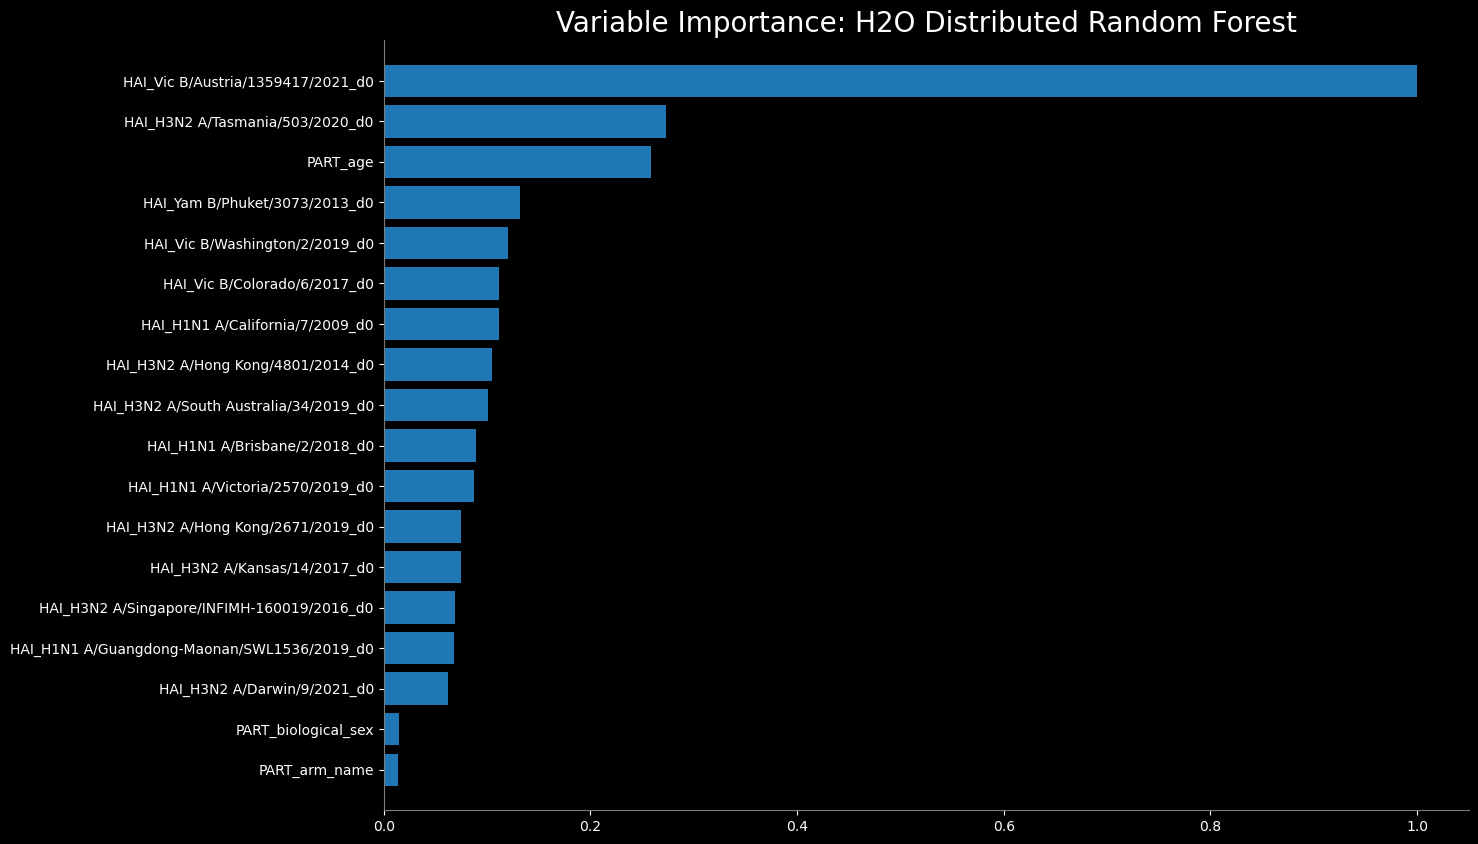

<Figure size 640x480 with 0 Axes>

In [21]:
print(f'Leader model: {top_model.model_id}')
varimp = top_model.varimp(use_pandas=True)
display(varimp.head(20))
top_model.varimp_plot(num_of_features=20)

In [22]:
challenge_hf = h2o.H2OFrame(challenge_data)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.3': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_3.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,Participant_ID,Task_4.3
0,2024_UGA.ID_077,43.027621
1,2024_UGA.ID_086,126.222278
2,2024_UGA.ID_128,18.592706
3,2024_UGA.ID_170,24.002053
4,2024_UGA.ID_179,74.370825
5,2024_UGA.ID_215,45.447800
6,2024_UGA.ID_219,46.284407
7,2024_UGA.ID_275,37.185412
8,2024_UGA.ID_295,107.112323
9,2024_UGA.ID_296,40.736322


In [23]:
h2o.cluster().shutdown()

H2O session _sid_93c2 closed.


---
## Conclusion

- **Leader model:** (fill after run)
- **CV Spearman:** (fill after run)

**Target:** log2 HAI titer for Vic B/Austria/1359417/2021 at D28. The pre-vaccination titer for the same strain (`HAI_Vic B/Austria/1359417/2021_d0`) is expected to be the strongest predictor.

Submission saved to `automl_submission/task_4_3.csv` (raw titer scale via `np.exp2`).